In [72]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from pathlib import Path


def get_engineered_df(file_path, warehouse="OE", max_time=300, work_code="30"):
    """
    Loads data and applies preprocessing/feature engineering
    Args:
    - warehouse: "OE" or "OF" to determine aisle grouping logic (default "OE")
    - file_path: path to the parquet file containing the data
    - max_time: maximum Time_Delta_sec to consider for filtering (default 300s)
    - work_code: WorkCode to filter on (default '30')
    Returns:
    - df: the processed DataFrame ready for modeling
    - feature_cols: list of columns to be used as features
    - cat_cols: list of categorical feature columns
    """
    # Load data
    df = pd.read_parquet(file_path)
    # Ensure Timestamp and basic numerics
    df["Timestamp"] = pd.to_datetime(df.get("Timestamp"), errors="coerce")
    for col in ["Time_Delta_sec", "Weight", "Cube", "Quantity", "Travel_Distance"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["WorkCode"] = df["WorkCode"].astype(str)
    df = df.dropna(subset=["Timestamp"]).copy()
    df = df[
        (df["Time_Delta_sec"] < max_time)
        & (df["Travel_Distance"] >= 0)
        & (df["WorkCode"] == work_code)
    ].copy()

    # Feature: Aisle Grouping, top-5 encoding
    top_aisles = df["Aisle"].value_counts().head(5).index
    df["Aisle"] = pd.to_numeric(df["Aisle"], errors="coerce").fillna(-1).astype(int)
    df["Aisle_group"] = df["Aisle"].apply(
        lambda a: str(a) if a in top_aisles else "other"
    )
    """
    if warehouse == "OE":
        if work_code == "30":
            freq_aisles = [39, 40, 41, 42]
        elif work_code == "20":
            freq_aisles = [23, 24, 25]
        elif work_code == "10":
            freq_aisles = [32, 33, 34, 35, 36]
    elif warehouse == "OF":
        if work_code == "30":
            freq_aisles = [70, 71, 72, 73, 74, 75]
        elif work_code == "20":
            freq_aisles = [29, 30]
        elif work_code == "10":
            freq_aisles = [22, 44]

    df["Aisle"] = pd.to_numeric(df["Aisle"], errors="coerce").fillna(-1).astype(int)
    df["Aisle_group"] = df["Aisle"].apply(
        lambda a: str(a) if a in freq_aisles else "other"
    )
    """

    # Feature: Level Grouping
    def level_group(l):
        try:
            val = int(l)
            return "5+" if val >= 5 else str(val)
        except:
            return str(l)

    df["Level_group"] = df["Level"].apply(level_group)

    # Feature: Time of Day Buckets
    df["hour"] = df["Timestamp"].dt.hour.astype(int)

    def tod_bucket(h):
        if 6 <= h < 12:
            return "6-12"
        elif 12 <= h < 16:
            return "12-4"
        elif 16 <= h < 20:
            return "4-8"
        elif 20 <= h <= 23:
            return "8-12"
        else:
            return "after_midnight"

    df["time_of_day"] = df["hour"].apply(tod_bucket)

    # Feature: UOM Grouping
    valid_uoms = ["EA", "BX", "PK", "CA", "CS"]
    df["UOM_group"] = df["UnitOfMeasure"].apply(
        lambda u: u if u in valid_uoms else "other"
    )

    # Feature: Day of Week
    df["day_of_week"] = df["Timestamp"].dt.day_name()

    # Feature: Relationship with Previous Row
    df["Prev_Aisle"] = (
        pd.to_numeric(df["Prev_Aisle"], errors="coerce").fillna(-1).astype(int)
    )
    df["same_aisle"] = (df["Aisle"] == df["Prev_Aisle"]).astype(int)
    df["same_lockey"] = (df["LocKey"] == df["PrevLocKey"]).astype(int)
    df["diff_level"] = (
        (df["LocKey"] == df["PrevLocKey"]) & (df["Level"] != df.get("Prev_Level"))
    ).astype(int)

    # Feature: Top 100 Products
    top_100_products = df["ProductID"].value_counts().head(100).index
    df["top_100_product"] = df["ProductID"].isin(top_100_products).astype(int)

    """
    # Feature: Define efficient user as those with average pick time in top 50% and total picks in top 50%
    worker_stats = df.groupby("UserID")["Time_Delta_sec"].agg(["mean", "count"])
    worker_stats["mean"] = worker_stats["mean"].rank(pct=True)
    worker_stats["count"] = worker_stats["count"].rank(pct=True)
    df = df.merge(worker_stats, on="UserID", how="left")
    df["efficient_user"] = ((df["mean"] <= 0.5) & (df["count"] <= 0.5)).astype(int)
    """

    # Final feature lists
    feature_cols = [
        "Travel_Distance",
        "Weight",
        "Cube",
        "Quantity",
        "Aisle_group",
        "Level_group",
        "time_of_day",
        "same_aisle",
        "same_lockey",
        "diff_level",
        "UOM_group",
        "day_of_week",
        "top_100_product",
        # "efficient_user",
    ]

    cat_cols = [
        "Aisle_group",
        "Level_group",
        "time_of_day",
        "same_aisle",
        "same_lockey",
        "diff_level",
        "UOM_group",
        "day_of_week",
        "top_100_product",
        # "efficient_user",
    ]

    return df, feature_cols, cat_cols

In [9]:
# Insert warehouse name here
warehouse_name = "OE"

# GitHub repo
base = "Lucas_Systems_Capstone_Project"

# Load your processed data
df, features, cat_cols = get_engineered_df("../data/processed/oe_detailed.parquet", warehouse="OE", work_code="30")
df

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Aisle_group,Level_group,hour,time_of_day,UOM_group,day_of_week,same_aisle,same_lockey,diff_level,top_100_product
1,PickPut,143,30,7717860,460,50,2025-09-08 12:12:18.127,422,2025-09-08 12:11:50.830,35192,...,other,2,12,12-4,EA,Monday,1,0,0,0
2,PickPut,143,30,7717908,460,100,2025-09-08 12:15:46.650,422,2025-09-08 12:12:18.127,422,...,other,2,12,12-4,EA,Monday,1,1,0,0
3,PickPut,143,30,7717921,44547,13,2025-09-08 12:16:30.470,10743,2025-09-08 12:15:46.650,422,...,other,2,12,12-4,EA,Monday,1,1,0,0
4,PickPut,143,30,7717920,44547,13,2025-09-08 12:18:00.970,10743,2025-09-08 12:16:30.470,10743,...,other,2,12,12-4,EA,Monday,1,1,0,0
5,PickPut,143,30,7717815,191,8,2025-09-08 12:18:45.173,2985,2025-09-08 12:18:00.970,10743,...,other,2,12,12-4,BX,Monday,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94388,PickPut,90,30,8033884,5376,1,2025-12-02 01:30:38.420,4226,2025-12-02 01:26:07.153,163440,...,other,2,1,after_midnight,EA,Tuesday,0,0,0,0
94389,PickPut,90,30,8033857,9249,1,2025-12-02 01:32:25.190,34149,2025-12-02 01:30:38.420,4226,...,other,3,1,after_midnight,EA,Tuesday,1,0,0,0
94390,PickPut,90,30,8033861,12811,1,2025-12-02 01:34:01.790,32150,2025-12-02 01:32:25.190,34149,...,other,2,1,after_midnight,EA,Tuesday,1,0,0,0
94399,PickPut,90,30,8039942,52330,6,2025-12-02 22:48:36.973,4710513,2025-12-02 22:48:36.767,4710513,...,other,1,22,8-12,EA,Tuesday,1,1,0,0


In [31]:
df_30 = df[df["WorkCode"] == "30"]
df_30 = df.loc[:, ["Time_Delta_sec"] + features + cat_cols]
med = np.median(df_30["Time_Delta_sec"])
df_30["Long Task"] = df_30["Time_Delta_sec"] > med
df_30.dropna(inplace=True)
df_30 = pd.get_dummies(df_30, columns=cat_cols)
df_30


,Time_Delta_sec,Travel_Distance,Weight,Cube,Quantity,Long Task,Aisle_group_other,Aisle_group_other,Level_group_1,Level_group_2,...,day_of_week_Tuesday,day_of_week_Wednesday,day_of_week_Monday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,top_100_product_0,top_100_product_1,top_100_product_0,top_100_product_1
1,27.297,21.0,0.0300,0.016,50,False,True,True,False,True,...,False,False,True,False,False,False,True,False,True,False
2,208.523,0.0,0.0300,0.016,100,True,True,True,False,True,...,False,False,True,False,False,False,True,False,True,False
3,43.820,0.0,0.5000,0.139,13,True,True,True,False,True,...,False,False,True,False,False,False,True,False,True,False
4,90.500,0.0,0.5000,0.139,13,True,True,True,False,True,...,False,False,True,False,False,False,True,False,True,False
5,44.203,43.0,1.4500,0.137,8,True,True,True,False,True,...,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94388,271.267,703.0,0.0888,0.013,1,True,True,True,False,True,...,True,False,False,False,True,False,True,False,True,False
94389,106.770,508.0,0.2250,0.090,1,True,True,True,False,False,...,True,False,False,False,True,False,True,False,True,False
94390,96.600,7.0,0.3100,0.031,1,True,True,True,False,True,...,True,False,False,False,True,False,True,False,True,False
94399,0.206,0.0,0.8250,0.302,6,False,True,True,True,False,...,True,False,False,False,True,False,True,False,True,False


In [73]:
X = df_30.drop(columns=["Time_Delta_sec", "Long Task"])
X = StandardScaler().fit_transform(X)
model = PCA(n_components=2, whiten=True)
model.fit(X)
X_pca = model.transform(X)
X_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
X_pca["Long Task"] = df_30["Long Task"].reset_index(drop=True)
X_pca

,PC1,PC2,Long Task
0,0.690912,0.069600,False
1,-0.327914,0.265116,True
2,-0.300877,0.372397,True
3,-0.300877,0.372397,True
4,0.771654,0.248505,True
...,...,...,...
65246,3.087515,2.718249,True
65247,1.405811,0.493046,True
65248,0.963837,0.287926,True
65249,-0.194475,0.308204,False


diff_level_1
top_100_product_0
top_100_product_0
top_100_product_1
top_100_product_1


Text(0.5, 1.0, 'PCA Plot of OE WorkCode 30')

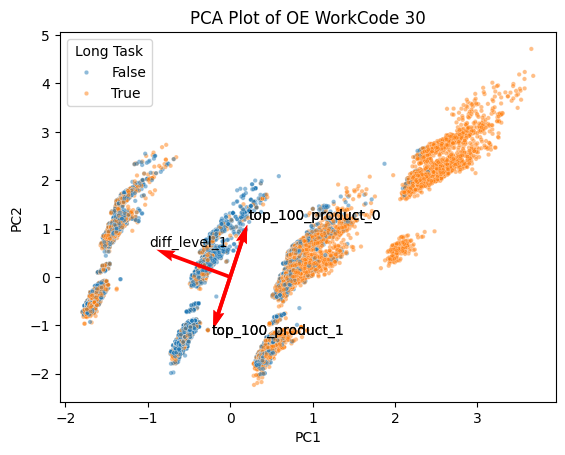

In [92]:
feature_names = df_30.drop(columns=["Time_Delta_sec", "Long Task"]).columns

# Loadings
loadings = model.components_.T

# Compute arrow lengths
importance = np.sqrt(loadings[:,0]**2 + loadings[:,1]**2)

# Get indices of top 3
top_idx = np.argsort(importance)[-5:]

sns.scatterplot(data=X_pca, x="PC1", y="PC2", s=10, hue="Long Task", alpha=0.5)

# Plot only top 3 arrows
scale = 3
for i in top_idx:
    plt.quiver(0, 0,
               loadings[i,0]*scale,
               loadings[i,1]*scale,
               angles='xy',
               scale_units='xy',
               scale=1,
               color='red')

    plt.text(loadings[i,0]*scale*1.1,
             loadings[i,1]*scale*1.1,
             feature_names[i])
    print(feature_names[i])

plt.title("PCA Plot of OE WorkCode 30")

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score
y = df_30["Long Task"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [71]:
model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=4)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"R-Squared: {r2:.4f}")

Accuracy: 0.7208
R-Squared: -0.1169
